In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulate_reflectance import simulate_reflectance_single  # votre fonction de simulation

In [2]:
# Définition des chemins
module_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
workspace_dir = os.path.abspath(os.path.join(module_dir, ".."))
data_dir = os.path.join(workspace_dir, "data")
CONFIGURATIONS_dir = os.path.join(workspace_dir, "CONFIGURATIONS")
combos_file = os.path.join(CONFIGURATIONS_dir, "geom_mat_combinations.json")

# Path Data
json_combined_path = os.path.join(data_dir, "combined_materials.json")

# Chargement des combinaisons depuis le fichier JSON
with open(combos_file, "r", encoding="utf-8") as f:
    data = json.load(f)
all_combos = data.get("ALL_COMBINED_CONFIGS", [])
if not all_combos:
    raise ValueError("Aucune combinaison trouvée dans geom_mat_combinations.json.")

# Sélection de la première combinaison ou choisir une autre configuration
combo = all_combos[0]
geometry = combo["geometry"]["geometry"]          # dictionnaire géométrique
material_config_list = combo["material"]["MATERIALS_CONFIG"]
df_config = pd.DataFrame(material_config_list)      # conversion en DataFrame
ri_overrides = combo["material"].get("RI_OVERRIDES", {})

In [3]:
# Paramètres de simulation fixes
lambda_fixed = 700  # en nm
wave = {"wavelength": lambda_fixed, "angle": 0, "polarization": 1}

# Variation du nombre de modes de 10 à 200 par pas de 5
n_modes = np.arange(1, 300, 1)
Rup_vals = []


for n in n_modes:
    # La fonction simulate_reflectance_single attend une liste de longueurs d'onde
    Rup, _ = simulate_reflectance_single([lambda_fixed], geometry, wave, df_config, 
                                  json_combined_path, n_mod=n, 
                                  ri_overrides=ri_overrides)
    # On récupère la première (et unique) valeur puisque lambda_range contient un seul élément
    Rup_vals.append(Rup[0])

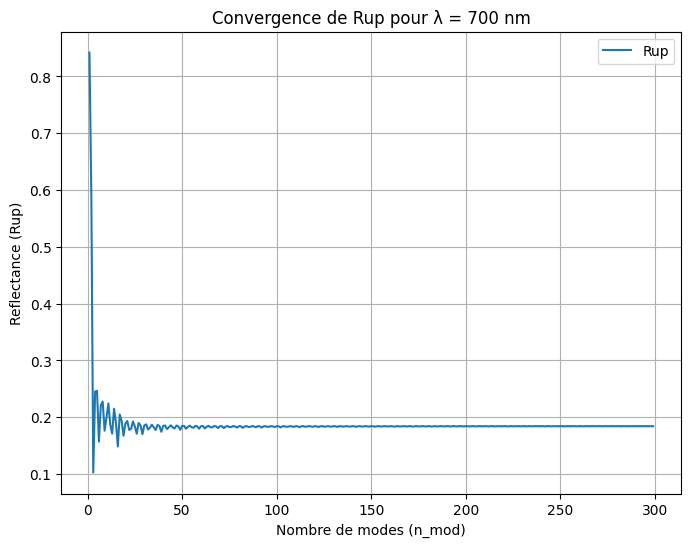

In [4]:
# Tracé de la convergence de Rup en fonction de n_mod
plt.figure(figsize=(8, 6))
plt.plot(n_modes, Rup_vals, label='Rup')
plt.xlabel("Nombre de modes (n_mod)")
plt.ylabel("Reflectance (Rup)")
plt.title(f"Convergence de Rup pour λ = {lambda_fixed} nm")
plt.legend()
plt.grid(True)



# 4) Sauvegarde
Images_dir = os.path.join(workspace_dir, "Images")
if not os.path.exists(Images_dir):
    os.makedirs(Images_dir)

fig_path = os.path.join(Images_dir, "convergence_Rup_Geom_S2_Mat_S2.png")
plt.savefig(fig_path, bbox_inches='tight')


plt.savefig("convergence_Rup_Geom_S2_Mat_S2.png")
plt.show()